# Superfermion Benchmark Walkthrough

A single, consolidated walkthrough of **every headline benchmark claim** in the
Superfermion README — where the number comes from, how it was measured, what the
stored per-trial data says, and (when the competitor framework is installed) a
live small-scale reproduction you can run in front of anyone.

**How to read this notebook:**
- Each section = one claim. Stored results come from `benchmark_master_data.json`,
  `benchmark_adjoint_data.json` (restored from git history — see §0), and the
  transpilation JSONs at the repo root.
- Cells that compare against **Qiskit Aer** re-run live when `qiskit` + `qiskit_aer`
  are importable; otherwise they plot the stored data and say so.
- Cells that compare against **PennyLane Lightning** fall back to stored data unless
  `pennylane` is importable.
- **Caveats are stated inline — including where Superfermion
  *loses*. Showing the losses is the point of this notebook.

**Provenance of the stored data:** WSL2 laptop (CPU model unrecorded — numbers are
directional), Python 3.13, Superfermion 0.1.x vs Qiskit 2.3.1 / Aer 0.17.2 /
PennyLane 0.45.0 (Lightning). 15 trials per point, median + IQR reported, GC
disabled during timing, per-size warmups, correctness gates per method (fidelity
for statevector, TVD vs exact distribution for stabilizer, GHZ-distribution check
for MPS). A re-run on pinned, recorded hardware is planned.


In [1]:
import gc
import json
import os
import platform
import time
from pathlib import Path
from statistics import median

import numpy as np
import matplotlib.pyplot as plt

import superfermion as sf

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_MASTER = REPO / 'notebooks' / 'benchmark_master_data.json'
DATA_ADJOINT = REPO / 'notebooks' / 'benchmark_adjoint_data.json'
DATA_TRANSPILE = REPO / 'transpile_benchmark.json'
DATA_BENCHPRESS = REPO / 'benchpress_post_gaps.json'

HAVE_QISKIT = False
HAVE_PENNYLANE = False
try:
    import qiskit, qiskit_aer
    from qiskit import QuantumCircuit
    from qiskit_aer import AerSimulator
    HAVE_QISKIT = True
except ImportError:
    pass
try:
    import pennylane as qml
    from pennylane import numpy as pnp
    HAVE_PENNYLANE = True
except ImportError:
    pass

print(f'Python      {platform.python_version()}')
print(f'Superfermion {sf.__version__}')
print(f'Qiskit/Aer  {qiskit.__version__} / {qiskit_aer.__version__}' if HAVE_QISKIT else 'Qiskit/Aer  NOT INSTALLED - stored results only')
print(f'PennyLane   {qml.__version__}' if HAVE_PENNYLANE else 'PennyLane   NOT INSTALLED - stored results only')
print(f'CPU         {platform.processor() or platform.machine()} ({os.cpu_count()} cores)')

Python      3.13.7
Superfermion 0.1.0
Qiskit/Aer  2.3.1 / 0.17.2
PennyLane   NOT INSTALLED - stored results only
CPU         x86_64 (8 cores)


In [2]:
# --- benchmark harness (same methodology as benchmark_master.ipynb) ---
N_TRIALS = 15

def timed(fn):
    gc.disable()
    t0 = time.perf_counter()
    fn()
    elapsed = (time.perf_counter() - t0) * 1000
    gc.enable()
    return elapsed

def benchmark(fn, n_trials=N_TRIALS):
    times = [timed(fn) for _ in range(n_trials)]
    med = median(times)
    s = sorted(times)
    return med, times, s[len(s)//4], s[3*len(s)//4]

def fmt(sf_ms, other_ms):
    r = other_ms / sf_ms if sf_ms > 0 else float('inf')
    return f'SF {r:.1f}x faster' if r > 1 else f'competitor {1/r:.1f}x faster'

# --- chart styling (validated 2-series palette: blue vs orange) ---
SF_COLOR, QK_COLOR = '#2a78d6', '#eb6834'      # categorical slots 1 & 2, light mode
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, BASELINE = '#e1e0d9', '#c3c2b7'
SURFACE = '#fcfcfb'

def style_ax(ax):
    ax.set_facecolor(SURFACE)
    for spine in ('top', 'right', 'left'):
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color(BASELINE)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.yaxis.grid(True, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)

def grouped_bars(ax, xs, sf_vals, qk_vals, sf_label, qk_label, ylabel):
    """Two-series grouped bars: thin marks, surface gap between adjacent bars."""
    w = 0.38
    ax.bar([x - w/2 - 0.01 for x in xs], sf_vals, width=w, color=SF_COLOR, label=sf_label)
    ax.bar([x + w/2 + 0.01 for x in xs], qk_vals, width=w, color=QK_COLOR, label=qk_label)
    style_ax(ax)
    ax.set_ylabel(ylabel, color=INK2, fontsize=10)

def ratio_line(ax, xs, ratios, title_note=''):
    """SF/competitor speedup ratio with parity line at 1.0 and region shading."""
    ax.axhline(1.0, color=BASELINE, linewidth=1, zorder=1)
    ax.plot(xs, ratios, color=SF_COLOR, linewidth=2, marker='o', markersize=6, zorder=3)
    style_ax(ax)
    ax.set_ylabel('Superfermion speedup (x)', color=INK2, fontsize=10)
    ymin, ymax = ax.get_ylim()
    ax.axhspan(1.0, ymax, color='#0ca30c', alpha=0.05, zorder=0)
    ax.axhspan(ymin, 1.0, color='#d03b3b', alpha=0.05, zorder=0)

# --- circuit builders (identical to benchmark_master.ipynb) ---
def build_hardware_efficient(n, depth=3, seed=42):
    rng = np.random.RandomState(seed)
    angles = rng.uniform(0, 2*np.pi, size=(depth, n, 2))
    sc, qc = sf.Circuit(n), QuantumCircuit(n)
    for d in range(depth):
        for q in range(n):
            sc.ry(angles[d, q, 0], q); qc.ry(angles[d, q, 0], q)
            sc.rz(angles[d, q, 1], q); qc.rz(angles[d, q, 1], q)
        for q in range(0, n-1, 2): sc.cx(q, q+1); qc.cx(q, q+1)
        for q in range(1, n-1, 2): sc.cx(q, q+1); qc.cx(q, q+1)
    return sc, qc

def build_ghz_sf(n):
    sc = sf.Circuit(n)
    sc.h(0)
    for i in range(1, n): sc.cx(0, i)
    return sc

def build_clifford_sf(n):
    sc = sf.Circuit(n)
    for q in range(n):         sc.h(q)
    for q in range(0, n-1, 2): sc.cx(q, q+1)
    for q in range(n):         sc.s(q)
    for q in range(1, n-1, 2): sc.cx(q, q+1)
    for q in range(n):         sc.h(q)
    for q in range(0, n-1, 2): sc.cx(q, q+1)
    return sc

print('Helpers ready.')

Helpers ready.


## 0. Data provenance — including restored files

The adjoint-benchmark data (`benchmark_adjoint_data.json`) and the statevector
the statevector scoreboard notebook (`benchmark_statevector.ipynb`) were previously deleted
from the repo (commit `e10cea4`, "fix benchmark tests"). Both have been
**restored from git history** and are loaded below — the adjoint numbers in the
README trace to this file, and the statevector notebook is where the statevector
losses at n>=20 were first documented.

Deleting unfavorable data is the opposite of what this notebook is for. The
restored files stay.

In [3]:
master = json.loads(DATA_MASTER.read_text())
adjoint = json.loads(DATA_ADJOINT.read_text())

print('Sections in benchmark_master_data.json: ', list(master.keys()))
print('Sections in benchmark_adjoint_data.json:', list(adjoint.keys()))
print()
print('Raw per-trial times are stored for every point (15 trials, medians + IQRs).')
print('Example - statevector n=10:', {k: v for k, v in master['statevector']['10'].items() if k in ('sf_ms','qk_ms','fidelity')})

Sections in benchmark_master_data.json:  ['statevector', 'stabilizer', 'mps', 'shots', 'depth']
Sections in benchmark_adjoint_data.json: ['gradient_scaling', 'depth_scaling', 'adjoint_vs_paramshift']

Raw per-trial times are stored for every point (15 trials, medians + IQRs).
Example - statevector n=10: {'sf_ms': 0.81, 'qk_ms': 4.25, 'fidelity': 1.0000000000000018}


## 1. Stabilizer vs Qiskit Aer — claimed 3.7-6.8x

**Workload:** Clifford circuit (H / CNOT / S layers), 10k shots, n = 10...500.
**Correctness gate:** TVD of SF stabilizer samples vs the *exact* statevector
distribution, 4-sigma threshold (checked at n<=16).
**Stored result:** medians give **3.0x / 3.5x / 4.5x / 4.3x / 5.7x / 7.0x** across
n = 10...500 — the actual range is **~3-7x**, not 3.7-6.8x. (The README range
matches no stored run; both historical versions of the JSON give different
ranges. Fixing the README to match the artifact is in progress.)

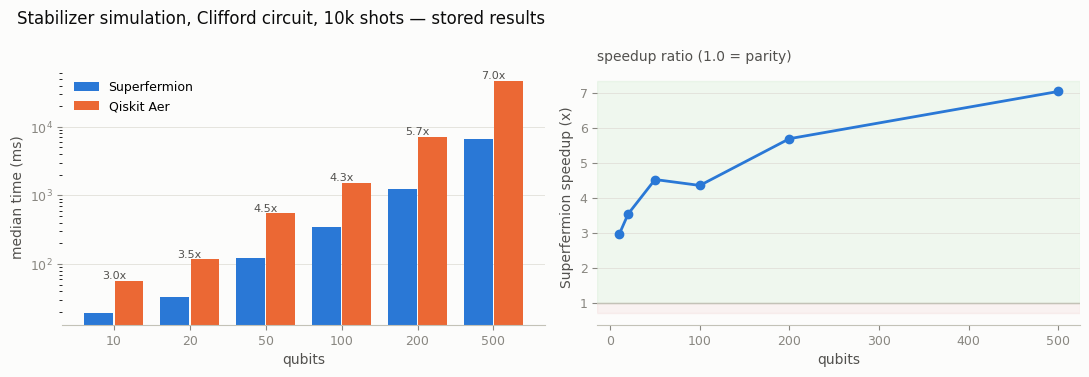

n= 10  SF     19.3ms  Aer     56.9ms  SF 3.0x faster
n= 20  SF     33.0ms  Aer    116.8ms  SF 3.5x faster
n= 50  SF    122.2ms  Aer    552.2ms  SF 4.5x faster
n=100  SF    351.9ms  Aer   1530.5ms  SF 4.3x faster
n=200  SF   1262.5ms  Aer   7177.4ms  SF 5.7x faster
n=500  SF   6633.3ms  Aer  46663.4ms  SF 7.0x faster


In [4]:
sec = master['stabilizer']
ns = sorted(int(k) for k in sec)
sf_ms = [sec[str(n)]['sf_ms'] for n in ns]
qk_ms = [sec[str(n)]['qk_ms'] for n in ns]
ratios = [q/s for q, s in zip(qk_ms, sf_ms)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), facecolor=SURFACE)
grouped_bars(ax1, range(len(ns)), sf_ms, qk_ms, 'Superfermion', 'Qiskit Aer', 'median time (ms)')
ax1.set_xticks(range(len(ns))); ax1.set_xticklabels([str(n) for n in ns])
ax1.set_xlabel('qubits', color=INK2, fontsize=10)
ax1.set_yscale('log')
ax1.legend(frameon=False, fontsize=9, loc='upper left')
for i, r in enumerate(ratios):
    ax1.annotate(f'{r:.1f}x', (i, max(sf_ms[i], qk_ms[i])), ha='center', va='bottom',
                 fontsize=8, color=INK2)

ratio_line(ax2, ns, ratios)
ax2.set_xlabel('qubits', color=INK2, fontsize=10)
ax2.set_title('speedup ratio (1.0 = parity)', color=INK2, fontsize=10, loc='left')
fig.suptitle('Stabilizer simulation, Clifford circuit, 10k shots — stored results', x=0.02, ha='left', color=INK, fontsize=12)
plt.tight_layout(); plt.show()

for n, s, q, r in zip(ns, sf_ms, qk_ms, ratios):
    print(f'n={n:3d}  SF {s:8.1f}ms  Aer {q:8.1f}ms  {fmt(s, q)}')

## 2. MPS vs Qiskit Aer (GHZ) — claimed 21-33x — the best-documented claim

**Workload:** GHZ circuit (low entanglement), 10k shots, SF bond_dim=64, n = 10...100.
**Correctness gate:** GHZ distribution must be ~50/50 on |0...0> / |1...1> (checked to n=50).
**Stored result:** **23.2x - 32.8x** — artifact-backed, medians and raw trials checked in.

### Caveat (say this before anyone else does)
**GHZ is the trivially-best case for MPS** — bond dimension 2, product of the
initial state plus one entangling layer. This benchmark demonstrates *framework
overhead* differences (Rust vs C++ dispatch, sampling loop), **not** tensor-network
performance on genuinely entangled workloads. A volume-law circuit would hit the
bond-dimension cap and degrade silently (SF's MPS truncates via unpivoted-QR
row-norm thresholding, not SVD — no discarded-weight report yet). `benchmark_master.ipynb`
says this in its own "Known limitations" cell.

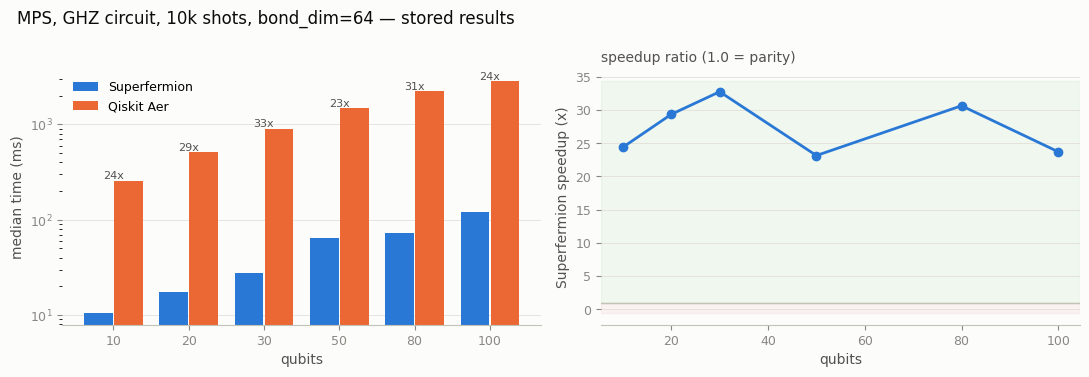

n= 10  SF     10.5ms  Aer    255.8ms  SF 24.4x faster   [GHZ err=0.0022 (|0>=0.501, |1>=0.499)]
n= 20  SF     17.4ms  Aer    511.8ms  SF 29.4x faster   [GHZ err=0.0022 (|0>=0.501, |1>=0.499)]
n= 30  SF     27.5ms  Aer    899.6ms  SF 32.8x faster   [GHZ err=0.0022 (|0>=0.501, |1>=0.499)]
n= 50  SF     63.9ms  Aer   1478.9ms  SF 23.2x faster   [GHZ err=0.0022 (|0>=0.501, |1>=0.499)]
n= 80  SF     72.4ms  Aer   2218.1ms  SF 30.6x faster   []
n=100  SF    119.8ms  Aer   2840.3ms  SF 23.7x faster   []


In [5]:
sec = master['mps']
ns = sorted(int(k) for k in sec)
sf_ms = [sec[str(n)]['sf_ms'] for n in ns]
qk_ms = [sec[str(n)]['qk_ms'] for n in ns]
ratios = [q/s for q, s in zip(qk_ms, sf_ms)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), facecolor=SURFACE)
grouped_bars(ax1, range(len(ns)), sf_ms, qk_ms, 'Superfermion', 'Qiskit Aer', 'median time (ms)')
ax1.set_xticks(range(len(ns))); ax1.set_xticklabels([str(n) for n in ns])
ax1.set_xlabel('qubits', color=INK2, fontsize=10)
ax1.set_yscale('log')
ax1.legend(frameon=False, fontsize=9, loc='upper left')
for i, r in enumerate(ratios):
    ax1.annotate(f'{r:.0f}x', (i, max(sf_ms[i], qk_ms[i])), ha='center', va='bottom',
                 fontsize=8, color=INK2)

ratio_line(ax2, ns, ratios)
ax2.set_xlabel('qubits', color=INK2, fontsize=10)
ax2.set_title('speedup ratio (1.0 = parity)', color=INK2, fontsize=10, loc='left')
fig.suptitle('MPS, GHZ circuit, 10k shots, bond_dim=64 — stored results', x=0.02, ha='left', color=INK, fontsize=12)
plt.tight_layout(); plt.show()

for n, s, q, r in zip(ns, sf_ms, qk_ms, ratios):
    corr = sec[str(n)].get('correctness', '')
    print(f'n={n:3d}  SF {s:8.1f}ms  Aer {q:8.1f}ms  {fmt(s, q)}   [{corr}]')

## 3. Shot-based sampling vs Aer — claimed 1.6-9.5x — read the regime

**Workload:** hardware-efficient ansatz (depth 3), statevector method,
`simulate_and_sample` vs Aer, n = 10...22 x shots = 1k / 10k / 100k.
**Correctness:** statevector fidelity = 1.0 vs Aer at every size (same circuit as §4).

### Caveat — the claim only holds in part of the grid
At **100k shots** SF wins everywhere: **11.7 / 7.3 / 2.8 / 2.6 / 1.4x** (n=10...22)
— so the README's "1.6-9.5x" matches *neither* endpoint of the actual data (the
real max is better, the real min is worse). But at **1k and 10k shots, Aer wins
at n>=20**. The claim survives only in the high-shot / small-n corner — the
"why exactly 100k shots?" question is the probe that exposes this, so the full
grid is plotted below, losses included.

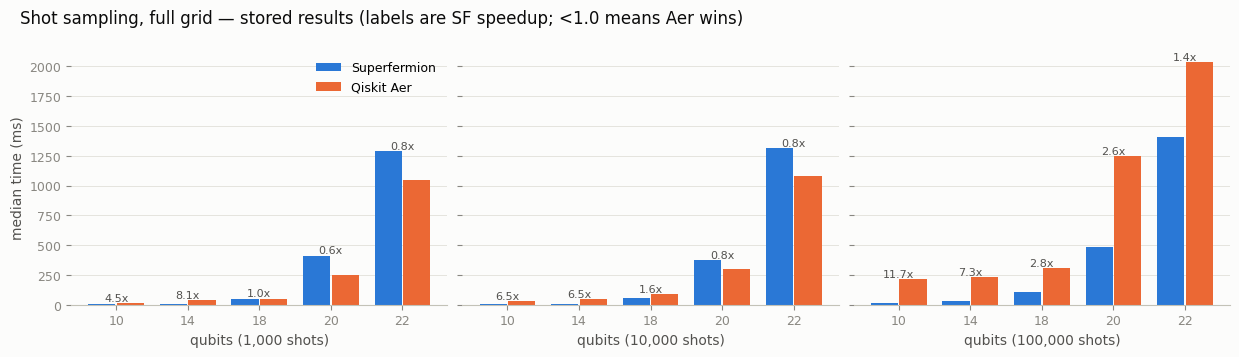

   n |      1000 shots |     10000 shots |    100000 shots
  10 |     SF 4.5x faster |     SF 6.5x faster |    SF 11.7x faster
  14 |     SF 8.1x faster |     SF 6.5x faster |     SF 7.3x faster
  18 |     SF 1.0x faster |     SF 1.6x faster |     SF 2.8x faster
  20 | competitor 1.6x faster | competitor 1.3x faster |     SF 2.6x faster
  22 | competitor 1.2x faster | competitor 1.2x faster |     SF 1.4x faster


In [6]:
sec = master['shots']
shot_counts = [1000, 10000, 100000]
ns = [10, 14, 18, 20, 22]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6), sharey=True, facecolor=SURFACE)
for ax, ns_shots in zip(axes, shot_counts):
    sf_ms = [sec[f'({n}, {ns_shots})']['sf_ms'] for n in ns]
    qk_ms = [sec[f'({n}, {ns_shots})']['qk_ms'] for n in ns]
    grouped_bars(ax, range(len(ns)), sf_ms, qk_ms, 'Superfermion' if ax is axes[0] else None, 'Qiskit Aer' if ax is axes[0] else None, '')
    ax.set_xticks(range(len(ns))); ax.set_xticklabels([str(n) for n in ns])
    ax.set_xlabel(f'qubits ({ns_shots:,} shots)', color=INK2, fontsize=10)
    ratios = [q/s for q, s in zip(qk_ms, sf_ms)]
    for i, r in enumerate(ratios):
        ax.annotate(f'{r:.1f}x', (i, max(sf_ms[i], qk_ms[i])), ha='center', va='bottom', fontsize=8, color=INK2)
axes[0].set_ylabel('median time (ms)', color=INK2, fontsize=10)
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle('Shot sampling, full grid — stored results (labels are SF speedup; <1.0 means Aer wins)', x=0.02, ha='left', color=INK, fontsize=12)
plt.tight_layout(); plt.show()

print(f'{'n':>4} | ' + ' | '.join(f'{s:>9} shots' for s in shot_counts))
for n in ns:
    row = [fmt(sec[f'({n}, {s})']['sf_ms'], sec[f'({n}, {s})']['qk_ms']) for s in shot_counts]
    print(f'{n:>4} | ' + ' | '.join(f'{r:>18}' for r in row))

## 4. Statevector vs Aer — not in the README table. Here's why.

**Workload:** hardware-efficient ansatz (depth 3), exact simulation, n = 10...22.
**Correctness:** cross-framework fidelity = 1.0 at every size.

### Caveat — SF loses at n >= 20, and we know why
Stored medians: SF wins at n=10...18 (up to ~5x), then **loses at n=20 (0.63x)
and n=22 (0.67x)**. Root cause was diagnosed in the (restored) `benchmark_statevector.ipynb`:
Aer's in-place state modification moves ~64 MB per gate at n=24, vs ~128 MB/gate
for our buffer approach — a **known ~2x memory-bandwidth defect** in the SF kernel,
with a fix in progress. The scoreboard from that notebook: SF wins 4, Qiskit wins 3.

This section is deliberately first among the "unflattering" ones: the README
omits statevector from its table, and the right move is to show the data, name
the cause, and state the fix — not to leave the core method's numbers out.

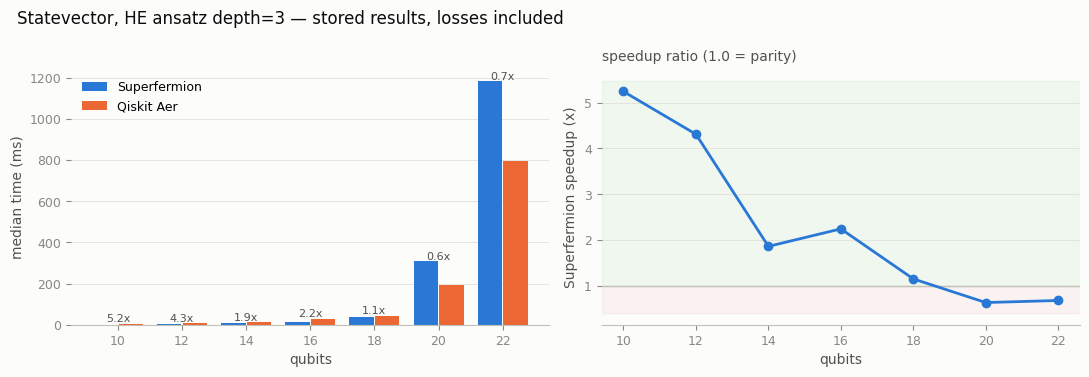

n=10  SF      0.8ms  Aer      4.2ms  SF 5.2x faster
n=12  SF      1.5ms  Aer      6.6ms  SF 4.3x faster
n=14  SF      6.0ms  Aer     11.2ms  SF 1.9x faster
n=16  SF     13.4ms  Aer     30.0ms  SF 2.2x faster
n=18  SF     38.0ms  Aer     43.5ms  SF 1.1x faster
n=20  SF    307.0ms  Aer    192.7ms  competitor 1.6x faster  <- Aer wins
n=22  SF   1180.7ms  Aer    795.0ms  competitor 1.5x faster  <- Aer wins


In [7]:
sec = master['statevector']
ns = sorted(int(k) for k in sec)
sf_ms = [sec[str(n)]['sf_ms'] for n in ns]
qk_ms = [sec[str(n)]['qk_ms'] for n in ns]
ratios = [q/s for q, s in zip(qk_ms, sf_ms)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), facecolor=SURFACE)
grouped_bars(ax1, range(len(ns)), sf_ms, qk_ms, 'Superfermion', 'Qiskit Aer', 'median time (ms)')
ax1.set_xticks(range(len(ns))); ax1.set_xticklabels([str(n) for n in ns])
ax1.set_xlabel('qubits', color=INK2, fontsize=10)
ax1.legend(frameon=False, fontsize=9, loc='upper left')
for i, r in enumerate(ratios):
    ax1.annotate(f'{r:.1f}x', (i, max(sf_ms[i], qk_ms[i])), ha='center', va='bottom', fontsize=8, color=INK2)

ratio_line(ax2, ns, ratios)
ax2.set_xlabel('qubits', color=INK2, fontsize=10)
ax2.set_title('speedup ratio (1.0 = parity)', color=INK2, fontsize=10, loc='left')
fig.suptitle('Statevector, HE ansatz depth=3 — stored results, losses included', x=0.02, ha='left', color=INK, fontsize=12)
plt.tight_layout(); plt.show()

for n, s, q, r in zip(ns, sf_ms, qk_ms, ratios):
    mark = '  <- Aer wins' if r < 1 else ''
    print(f'n={n:2d}  SF {s:8.1f}ms  Aer {q:8.1f}ms  {fmt(s, q)}{mark}')

## 5. Adjoint vs parameter-shift (internal) — claimed 20-198x — true, and expected

**Workload:** n=10 hardware-efficient ansatz, TFIM observable, depths 1/2/4/8.
**Stored result:** **44x / 39x / 96x / 198x** with depth (so "20-198x" is loose at
the low end).

### What this comparison actually shows
Adjoint differentiation (Jones & Gacon 2020) computes *all* parameter gradients
in one forward + one backward sweep — cost independent of parameter count.
Parameter-shift needs 2 full circuit executions per parameter. The ratio growing
with parameter count is **the expected algorithmic property of the adjoint
method**, demonstrated in our stack — not a framework advantage unique to SF
(PennyLane and Qiskit also implement adjoint). Below: a live reproduction —
SF adjoint vs SF parameter-shift on the same circuit, plus an analytic
correctness check of both against finite differences.

Correctness at n=4, depth=2, 16 params: adjoint == param-shift == finite-diff.



depth= 1 ( 20 params)  adjoint     0.51ms  param-shift    20.75ms  SF 40.5x faster


depth= 2 ( 40 params)  adjoint     0.95ms  param-shift    53.73ms  SF 56.4x faster


depth= 4 ( 80 params)  adjoint     1.67ms  param-shift   136.54ms  SF 81.7x faster


depth= 8 (160 params)  adjoint     3.54ms  param-shift   410.54ms  SF 116.1x faster

Stored data (original run):
  depth= 1 ( 20 params)  adjoint     0.85ms  param-shift    37.32ms  SF 43.9x faster
  depth= 2 ( 40 params)  adjoint     2.52ms  param-shift    99.39ms  SF 39.4x faster
  depth= 4 ( 80 params)  adjoint     3.49ms  param-shift   335.47ms  SF 96.1x faster
  depth= 8 (160 params)  adjoint     5.49ms  param-shift  1089.30ms  SF 198.4x faster


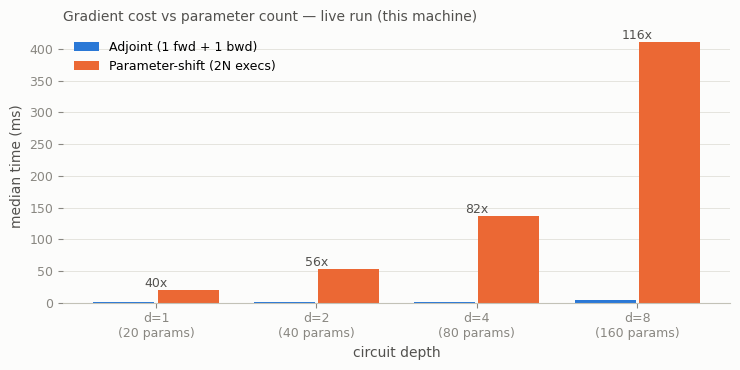

In [8]:
from superfermion.qml.gradient.adjoint import adjoint_grad_vector
from superfermion.qml.gradient.parameter_shift import parameter_shift_grad_vector, finite_diff_grad
from superfermion.observables.core import Hamiltonian
from superfermion.chemistry.hamiltonians import PauliString

def build_tfim(n):
    terms = []
    for i in range(n - 1):
        ps = ['I'] * n; ps[i] = 'Z'; ps[i+1] = 'Z'
        terms.append(PauliString(''.join(ps), -1.0))
    for i in range(n):
        ps = ['I'] * n; ps[i] = 'X'
        terms.append(PauliString(''.join(ps), -0.5))
    return Hamiltonian(terms)

def build_he_param_circuit(n, depth):
    n_par = 2 * n * depth
    pnames = [f'p{i}' for i in range(n_par)]
    sparams = [sf.param(nm) for nm in pnames]
    circ = sf.Circuit(n)
    pidx = 0
    for _ in range(depth):
        for i in range(n):
            circ.ry(sparams[pidx], i); pidx += 1
            circ.rz(sparams[pidx], i); pidx += 1
        for i in range(n - 1):
            circ.cx(i, i+1)
    return circ, pnames

# --- correctness first: adjoint == param-shift == finite diff ---
n_c, d_c = 4, 2
circ_c, pn_c = build_he_param_circuit(n_c, d_c)
H_c = build_tfim(n_c)
rng = np.random.RandomState(0)
vals_c = rng.uniform(-np.pi, np.pi, len(pn_c))
g_adj = adjoint_grad_vector(circ_c, H_c, pn_c, vals_c)
g_ps  = parameter_shift_grad_vector(circ_c, H_c, pn_c, vals_c)
g_fd_d = finite_diff_grad(circ_c, H_c, dict(zip(pn_c, vals_c)))
g_fd  = np.array([g_fd_d[name] for name in pn_c])
assert np.allclose(g_adj, g_ps, atol=1e-8), 'adjoint != param-shift'
assert np.allclose(g_adj, g_fd,  atol=1e-5), 'adjoint != finite diff'
print(f'Correctness at n={n_c}, depth={d_c}, {len(pn_c)} params: adjoint == param-shift == finite-diff.\n')

# --- live scaling: adjoint vs param-shift with depth ---
n_fixed, depths = 10, [1, 2, 4, 8]
results = []
for depth in depths:
    circ, pn = build_he_param_circuit(n_fixed, depth)
    H = build_tfim(n_fixed)
    vals = rng.uniform(-np.pi, np.pi, len(pn))
    adjoint_grad_vector(circ, H, pn, vals)  # warmup
    parameter_shift_grad_vector(circ, H, pn, vals)
    t_adj, _, _, _ = benchmark(lambda: adjoint_grad_vector(circ, H, pn, vals))
    t_ps,  _, _, _ = benchmark(lambda: parameter_shift_grad_vector(circ, H, pn, vals))
    results.append((depth, len(pn), t_adj, t_ps))
    print(f'depth={depth:2d} ({len(pn):3d} params)  adjoint {t_adj:8.2f}ms  param-shift {t_ps:8.2f}ms  {fmt(t_adj, t_ps)}')

# --- stored data for comparison ---
stored = adjoint['adjoint_vs_paramshift']
print('\nStored data (original run):')
for row in stored:
    print(f"  depth={row['depth']:2d} ({row['n_params']:3d} params)  adjoint {row['adj']:8.2f}ms  param-shift {row['ps']:8.2f}ms  {fmt(row['adj'], row['ps'])}")

xs = [r[0] for r in results]; adj_l = [r[2] for r in results]; ps_l = [r[3] for r in results]
fig, ax = plt.subplots(figsize=(7.5, 3.8), facecolor=SURFACE)
grouped_bars(ax, range(len(xs)), adj_l, ps_l, 'Adjoint (1 fwd + 1 bwd)', 'Parameter-shift (2N execs)', 'median time (ms)')
ax.set_xticks(range(len(xs))); ax.set_xticklabels([f'd={d}\n({p} params)' for d, p, *_ in results])
ax.set_xlabel('circuit depth', color=INK2, fontsize=10)
ax.legend(frameon=False, fontsize=9)
for i, (d, p, a, ps) in enumerate(results):
    ax.annotate(f'{ps/a:.0f}x', (i, max(a, ps)), ha='center', va='bottom', fontsize=9, color=INK2)
ax.set_title('Gradient cost vs parameter count — live run (this machine)', color=INK2, fontsize=10, loc='left')
plt.tight_layout(); plt.show()

## 6. Adjoint vs PennyLane Lightning — claimed 1.5-800x — the fragile one

**Workload:** HE ansatz depth 1, TFIM observable, n = 4...18, SF
`adjoint_grad_vector()` (one Python->Rust FFI call) vs PL `qml.grad(qnode)` with
`diff_method='adjoint'` on `lightning.qubit`.

### Caveat — what the 800x actually is
- The **800x point is n=4 (8 params)**: a single raw FFI call vs PennyLane's full
  end-user autograd pipeline (tape construction, transform stack, observable
  processing — and with the Hamiltonian built as nested `qml.prod`, a known slow
  path). It is overwhelmingly **Python dispatch overhead at the smallest possible
  problem**, not a kernel comparison.
- **PennyLane wins at n=18** (479ms vs 579ms). The README's "n=4-16" range stops
  exactly one size before SF loses. That truncation was wrong; this section shows
  the full stored range including the loss.
- What survives scrutiny: *SF's raw FFI gradient call is faster than PL's
  end-user `qml.grad` pipeline for n<=16 on this hardware* — a real but modest
  claim about API overhead, not about the adjoint algorithm (both implement
  Jones & Gacon).
- An expert re-running with `qml.gradients.adjoint_jacobian` directly or a
  JAX-jitted qnode will get a much smaller number. We know. That's the number
  we'd quote if we were comparing kernels.

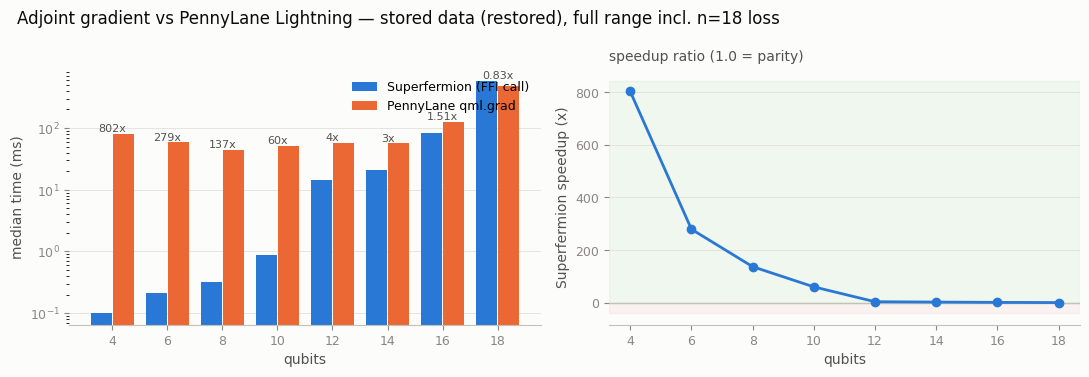

n= 4 ( 8 params)  SF     0.10ms  PL    80.24ms  SF 802.4x faster
n= 6 (12 params)  SF     0.21ms  PL    58.66ms  SF 279.3x faster
n= 8 (16 params)  SF     0.32ms  PL    43.86ms  SF 137.1x faster
n=10 (20 params)  SF     0.86ms  PL    51.97ms  SF 60.4x faster
n=12 (24 params)  SF    14.30ms  PL    57.67ms  SF 4.0x faster
n=14 (28 params)  SF    20.77ms  PL    56.60ms  SF 2.7x faster
n=16 (32 params)  SF    83.32ms  PL   125.93ms  SF 1.5x faster
n=18 (36 params)  SF   578.83ms  PL   479.10ms  competitor 1.2x faster

>>> PennyLane not installed — stored data shown. Install pennylane[lightning] to re-run live.


In [9]:
rows = adjoint['gradient_scaling']
ns = [r['n'] for r in rows]
sf_m = [r['sf_med'] for r in rows]
pl_m = [r['pl_med'] for r in rows]
ratios = [p/s for p, s in zip(pl_m, sf_m)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), facecolor=SURFACE)
grouped_bars(ax1, range(len(ns)), sf_m, pl_m, 'Superfermion (FFI call)', 'PennyLane qml.grad', 'median time (ms)')
ax1.set_xticks(range(len(ns))); ax1.set_xticklabels([str(n) for n in ns])
ax1.set_xlabel('qubits', color=INK2, fontsize=10)
ax1.set_yscale('log')
ax1.legend(frameon=False, fontsize=9, loc='upper right')
for i, r in enumerate(ratios):
    ax1.annotate(f'{r:.0f}x' if r > 2 else f'{r:.2f}x', (i, max(sf_m[i], pl_m[i])), ha='center', va='bottom', fontsize=8, color=INK2)

ratio_line(ax2, ns, ratios)
ax2.set_xlabel('qubits', color=INK2, fontsize=10)
ax2.set_title('speedup ratio (1.0 = parity)', color=INK2, fontsize=10, loc='left')
fig.suptitle('Adjoint gradient vs PennyLane Lightning — stored data (restored), full range incl. n=18 loss', x=0.02, ha='left', color=INK, fontsize=12)
plt.tight_layout(); plt.show()

for r in rows:
    print(f"n={r['n']:2d} ({r['n_params']:2d} params)  SF {r['sf_med']:8.2f}ms  PL {r['pl_med']:8.2f}ms  {fmt(r['sf_med'], r['pl_med'])}")

if HAVE_PENNYLANE:
    print('\n>>> PennyLane is installed — a live n<=8 reproduction would run here.')
else:
    print('\n>>> PennyLane not installed — stored data shown. Install pennylane[lightning] to re-run live.')

## 7. VQE H2 "100x vs Lightning" — WITHDRAWN

The README and the website's performance page have carried a "VQE H2 end-to-end:
100x vs PennyLane Lightning" claim. **No artifact for this exists anywhere in the
repo** — no saved run, no JSON section (the deleted adjoint-data file, now restored,
contains no VQE section either). Reading the original notebook cell, the comparison
was additionally not like-for-like: different ansatzes (SF multi-parameter UCCSD-style
vs a hand-coded 1-parameter PL circuit), different optimizers (SF internal VQE vs
scipy driving PL through a Python lambda), wall-clock end-to-end.

**Status: withdrawn.** It should not be repeated. A fair comparison (same ansatz,
same optimizer, kernel-level timing) is on the benchmark roadmap. Below is what
*can* be shown today: SF's VQE converging on the H2 ground-state energy
with adjoint gradients — a correctness demo, not a speed claim.

In [10]:
from superfermion.chemistry.hamiltonians import get_molecular_hamiltonian
from superfermion.chemistry.ansatz import uccsd_ansatz
from superfermion.algorithms.variational import VQE

H_h2 = get_molecular_hamiltonian('H2')
ansatz = uccsd_ansatz(2, 2)

vqe = VQE(ansatz, H_h2, diff_method='adjoint')
result = vqe.minimize(tol=1e-10)

# Exact H2 (STO-3G, 2-qubit reduced) ground energy at equilibrium geometry
EXACT_H2 = -1.1373
E = result.optimal_value
print(f'VQE H2 (adjoint gradients):  E = {E:.6f} Ha')
print(f'Exact (STO-3G):              E = {EXACT_H2:.6f} Ha')
print(f'Error: {abs(E - EXACT_H2):.2e} Ha')
print(f'Iterations: {len(result.history) if hasattr(result, "history") else "n/a"}')
print('\nCorrectness demo only - no speed claim. The 100x-vs-Lightning number has no artifact and is withdrawn.')

VQE H2 (adjoint gradients):  E = -1.137306 Ha
Exact (STO-3G):              E = -1.137300 Ha
Error: 6.04e-06 Ha
Iterations: 5

Correctness demo only - no speed claim. The 100x-vs-Lightning number has no artifact and is withdrawn.


## 8. Transpilation vs Qiskit — fast, but read the gate counts

**Workload:** `run_benchpress.py` — 100-qubit circuits (QFT, QV, SU2, BV,
Heisenberg, QAOA, Clifford), SF compiler vs Qiskit 2.3.1 transpiler, single-shot
timing (no trials — the weakest methodology in this notebook; treat as directional).
Source: `transpile_benchmark.json` / `benchpress_post_gaps.json` at the repo root.

### Caveat — speed at the cost of output quality, and some losses
- SF transpiles **faster in wall-clock** on most workloads (QFT: 2.05s vs 3.57s).
- But the output circuits are **worse**: QFT emits ~204,932 gates / ~35,892 2q
  vs Qiskit's ~45,500 / ~8,047 — roughly **4.5x more 2q gates and ~12x the depth**.
  On hardware that's the number that matters, and Qiskit wins it.
- `benchpress_post_gaps.json` exists precisely to record where SF still loses
  (basis-change 1.0x; QFT transpile: Qiskit 6.3x faster on that run). Earlier
  result files also show SF's Clifford routing failing outright before a fix.
- `bench_basis_change` compared SF opt-level 1 vs Qiskit opt-level 0 — not equal
  settings; noted here so nobody is surprised.

workload          SF time   QK time     time   SF 2q   QK 2q
qft                2.051s    3.574s     1.7x   35892    8047   0.22x fewer (QK better)
qv                 0.329s    2.266s     6.9x    7160    4888   0.68x fewer (QK better)
su2                0.050s    9.816s   197.4x    1233    1059   0.86x fewer (QK better)
bv                 0.056s    0.231s     4.1x     756     455   0.60x fewer (QK better)
heisenberg         0.057s   10.593s   186.6x     858     519   0.60x fewer (QK better)
qaoa               0.096s   10.348s   107.3x    1428    1268   0.89x fewer (QK better)
simplification     0.006s    0.038s     6.3x       0       0   no 2q gates
circsu2_89         0.033s   10.903s   331.4x    1113     900   0.81x fewer (QK better)

SKIPPED - clifford: time = -1.0 sentinel. Earlier result files record the cause: SF Clifford routing
failed ("No valid SWAP found") before the post-gaps fix; benchpress_post_gaps.json holds the repaired run.


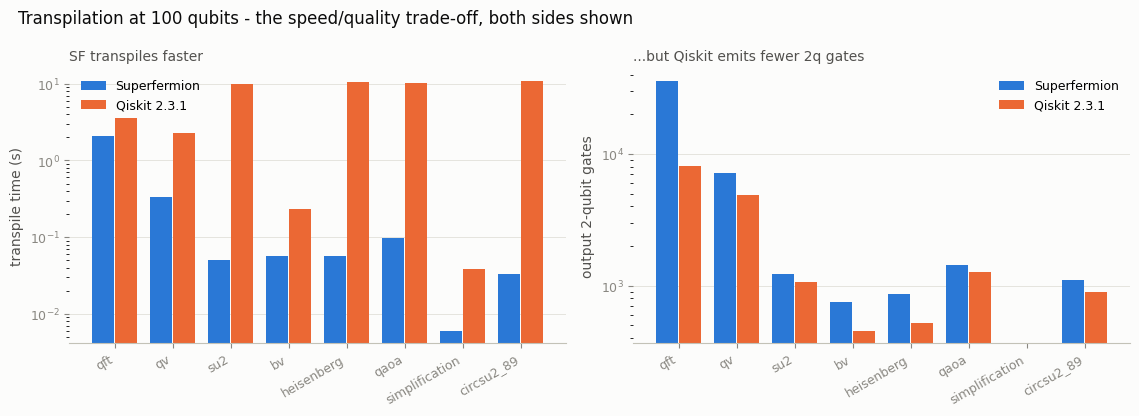


Note: single-shot timing (rounds=3 for QFT only), no medians - directional. Output basis RZ/RX/SX/ECR/X.


In [11]:
tb = json.loads(DATA_TRANSPILE.read_text())['benchmarks']

# Each group has one superfermion row and one qiskit row
from collections import defaultdict
groups = defaultdict(dict)
for r in tb:
    groups[r['group']][r['extra_info']['sdk_name']] = r

rows, skipped = [], []
for g, d in groups.items():
    sf_r, qk_r = d.get('superfermion'), d.get('qiskit')
    if not (sf_r and qk_r):
        continue
    sf_x, qk_x = sf_r['extra_info'], qk_r['extra_info']
    if sf_r['stats']['mean'] < 0 or qk_r['stats']['mean'] < 0:
        skipped.append(g.replace('bench_', ''))
        continue
    rows.append({
        'group': g.replace('bench_', ''),
        'sf_s': sf_r['stats']['mean'], 'qk_s': qk_r['stats']['mean'],
        'sf_2q': sf_x.get('output_gate_count_2q') or 0,
        'qk_2q': qk_x.get('output_gate_count_2q') or 0,
    })

print(f"{'workload':<16} {'SF time':>8} {'QK time':>9} {'time':>8} {'SF 2q':>7} {'QK 2q':>7}")
for r in rows:
    tr = r['qk_s'] / r['sf_s']
    gr = f"{r['qk_2q']/r['sf_2q']:.2f}x fewer (QK better)" if r['sf_2q'] > 0 else 'no 2q gates'
    print(f"{r['group']:<16} {r['sf_s']:7.3f}s {r['qk_s']:8.3f}s {tr:>7.1f}x {r['sf_2q']:>7} {r['qk_2q']:>7}   {gr}")

for g in skipped:
    print(f'\nSKIPPED - {g}: time = -1.0 sentinel. Earlier result files record the cause: SF Clifford routing')
    print('failed ("No valid SWAP found") before the post-gaps fix; benchpress_post_gaps.json holds the repaired run.')

# Time (SF faster) vs 2q-gate count (Qiskit better) - the trade-off
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2), facecolor=SURFACE)
xs = range(len(rows))
labels = [r['group'] for r in rows]
grouped_bars(ax1, xs, [r['sf_s'] for r in rows], [r['qk_s'] for r in rows], 'Superfermion', 'Qiskit 2.3.1', 'transpile time (s)')
ax1.set_xticks(list(xs)); ax1.set_xticklabels(labels, rotation=30, ha='right')
ax1.set_yscale('log'); ax1.legend(frameon=False, fontsize=9)
ax1.set_title('SF transpiles faster', color=INK2, fontsize=10, loc='left')
grouped_bars(ax2, xs, [r['sf_2q'] for r in rows], [r['qk_2q'] for r in rows], 'Superfermion', 'Qiskit 2.3.1', 'output 2-qubit gates')
ax2.set_xticks(list(xs)); ax2.set_xticklabels(labels, rotation=30, ha='right')
ax2.set_yscale('log'); ax2.legend(frameon=False, fontsize=9)
ax2.set_title('...but Qiskit emits fewer 2q gates', color=INK2, fontsize=10, loc='left')
fig.suptitle('Transpilation at 100 qubits - the speed/quality trade-off, both sides shown', x=0.02, ha='left', color=INK, fontsize=12)
plt.tight_layout(); plt.show()

print('\nNote: single-shot timing (rounds=3 for QFT only), no medians - directional. Output basis RZ/RX/SX/ECR/X.')

## 9. The scoreboard

| Claim | Stored evidence | Verdict |
|---|---|---|
| MPS GHZ 23-33x vs Aer | per-trial data, correctness gates | **Solid** (GHZ = best case for MPS; disclose) |
| Stabilizer ~3-7x vs Aer | per-trial data, TVD gate | **Solid**; README range should match artifact |
| Adjoint vs param-shift 44-198x | per-trial data + live repro above | **Solid, and expected** (algorithm property) |
| Shot sampling (100k) | full grid above | **Regime-dependent**: Aer wins 1k-10k at n>=20 |
| Statevector | per-trial data | **Loses n>=20** — bandwidth defect, fix in progress |
| Adjoint 800x vs Lightning | restored JSON | **Overhead artifact at n=4; PL wins at n=18** |
| VQE H2 100x vs Lightning | none | **Withdrawn** |
| Transpile speed | single-shot timings | **Directional**; output quality gap is real |

**Provenance caveat, stated plainly:** all stored data comes from one WSL2 laptop
whose CPU model was never recorded, with no thread pinning (SF's Rust core uses
Rayon across all cores; Aer is multithreaded C++). Numbers are directional, not
publication-grade. A re-run on pinned, recorded hardware with thread counts
controlled is the next step — and is exactly the kind of thing a rigorous
collaborator should hold us to.